# Loan Acceptance Prediction: Decision Tree Modeling and Optimization

**Liqi Liang** | Penn MSSP Machine Learning Project (MSSP 6080)

This project uses LendingClub loan application data to build and iteratively improve a binary classifier that predicts whether a loan application will be accepted. Part 1 establishes a baseline decision tree model. Part 2 systematically explores five optimization strategies — feature engineering, training set size, model type, hyperparameter tuning, and cross-validation — to identify the best-performing configuration.

**Dataset:** 81,103 LendingClub loan applications with borrower financial attributes (loan amount, FICO score, debt-to-income ratio, employment length, geographic region, loan purpose).

**Target variable:** `policy_code` (1 = Accepted, 0 = Rejected)

## Setup

In [ ]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=0B5qTk6DHjanhOV9LRE5DY3l1T2pGemVBNTVQVzVsMlFCcHF3' -O lendingclub.csv

--2025-02-12 04:31:05--  https://docs.google.com/uc?export=download&id=0B5qTk6DHjanhOV9LRE5DY3l1T2pGemVBNTVQVzVsMlFCcHF3
Resolving docs.google.com (docs.google.com)... 172.217.218.102, 172.217.218.139, 172.217.218.138, ...
Connecting to docs.google.com (docs.google.com)|172.217.218.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=0B5qTk6DHjanhOV9LRE5DY3l1T2pGemVBNTVQVzVsMlFCcHF3&export=download [following]
--2025-02-12 04:31:05--  https://drive.usercontent.google.com/download?id=0B5qTk6DHjanhOV9LRE5DY3l1T2pGemVBNTVQVzVsMlFCcHF3&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.153.132, 2a00:1450:4013:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.153.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6325329 (6.0M) [application/octet-stream]
Saving to: ‘lendingclub.csv’

lendingclub.cs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
lcdf = pd.read_csv("/content/drive/MyDrive/MSSP 6080/lendingclub.csv")

## Part 1: Baseline Decision Tree

I first explore the dataset to understand feature distributions and class imbalance, then train a decision tree classifier using four financial features: loan amount, FICO score, debt-to-income ratio, and employment length.

### 1.1 Data Exploration

In [ ]:
lcdf.head(10)

,amount,date,title,fico,dti,zip,state,emp_length,policy_code,year,outcome
0,2500.0,Dec-2011,bike,740.0,1.00,309xx,GA,< 1 year,1.0,2011,accept
1,12000.0,Dec-2011,Consolidation,675.0,10.78,913xx,CA,10+ years,1.0,2011,accept
2,21000.0,Dec-2011,Debt Cleanup,705.0,13.22,335xx,FL,10+ years,1.0,2011,accept
3,31825.0,Dec-2011,Debt Consolidation Loan,760.0,14.03,080xx,NJ,5 years,1.0,2011,accept
4,12000.0,Dec-2011,Debt Consolidation,725.0,16.70,088xx,NJ,10+ years,1.0,2011,accept
5,25600.0,Dec-2011,Credit card refinance loan,725.0,15.71,913xx,CA,9 years,1.0,2011,accept
6,17500.0,Dec-2011,Start Up,705.0,19.47,951xx,CA,6 years,1.0,2011,accept
7,6400.0,Dec-2011,Help,660.0,20.22,923xx,CA,5 years,1.0,2011,accept
8,10000.0,Dec-2011,CC Refi Loan,680.0,15.39,191xx,PA,2 years,1.0,2011,accept
9,7000.0,Dec-2011,Credit Card Consolidation,685.0,5.38,559xx,MN,3 years,1.0,2011,accept


In [ ]:
print(lcdf.columns)

Index(['amount', 'date', 'title', 'fico', 'dti', 'zip', 'state', 'emp_length',
       'policy_code', 'year', 'outcome'],
      dtype='object')


In [ ]:
print(lcdf.dtypes)

amount         float64
date            object
title           object
fico           float64
dti            float64
zip             object
state           object
emp_length      object
policy_code    float64
year             int64
outcome         object
dtype: object


In [ ]:
float_columns = lcdf.select_dtypes(include=['float64']).columns
lcdf_mean = lcdf.groupby("outcome")[float_columns].mean()
print(lcdf_mean)

               amount        fico         dti  policy_code
outcome                                                   
accept   12492.550027  706.341806   15.187413          1.0
reject   13019.506016  589.716775  578.479662          0.0


### 1.2 Feature Engineering: Employment Length

In [ ]:
lcdf["emp_length"].replace("< 1 year",0, inplace=True)  #replace values less than 1 year to 0
lcdf["emp_length"].replace("10+ years",11, inplace=True)  #replace values more than 10 year to 11

emp_years = [] # create a new variable to store

for i in np.arange(len(lcdf["emp_length"])):
  years_string = str(lcdf.iloc[i,7]).split()
  years_float = float(years_string[0])
  emp_years.append(years_float) #replace "x years" with "x"

lcdf["emp_years"] = emp_years #add new variable to lcdf data

<ipython-input-10-95e0ea948a46>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lcdf["emp_length"].replace("< 1 year",0, inplace=True)  #replace values less than 1 year to 0
<ipython-input-10-95e0ea948a46>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'd

### 1.3 Model Training

In [ ]:
lcdf["outcome"] = lcdf["outcome"].map({"accept":1,"reject":0}) #change 'outcome' to dummy variable

In [ ]:
lcdfx = lcdf[["amount", "fico", "dti", "emp_years"]] #select x variables

In [ ]:
lcdfy = lcdf["policy_code"] #select y variable

In [ ]:
# Use scikit-learn to create our train/test split and train our decision tree

X_train, X_test, y_train, y_test = train_test_split(lcdfx,lcdfy,test_size=0.30, random_state=1) #30% testing data, 70% training data
model = DecisionTreeClassifier(criterion="entropy", random_state=1).fit(X_train, y_train) #use entropy as criterion

### 1.4 Model Evaluation

In [ ]:
# Calculate our accuracy on the train and test sets

train_pred = model.predict(X_train)
train_accuracy = 100*accuracy_score(y_train, train_pred)

test_pred = model.predict(X_test)
test_accuracy = 100*accuracy_score(y_test, test_pred)

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 94.59%


In [ ]:
print("Class distribution in decision tree:", model.classes_)

Class distribution in decision tree: [0. 1.]


In [ ]:
class_distribution = lcdf.groupby("policy_code").count()
print(class_distribution)

             amount   date  title   fico    dti    zip  state  emp_length  \
policy_code                                                                 
0.0           71858  71858  71858  71858  71858  71858  71858       71858   
1.0            9245   9245   9245   9245   9245   9245   9245        9245   

              year  outcome  emp_years  
policy_code                             
0.0          71858    71858      71858  
1.0           9245     9245       9245  


In [ ]:
# (same as above) provide their name and data type
print(lcdf.dtypes)
# provide the min, mean, and max values
stats = lcdfx.describe().loc[["min", "mean", "max"]]
print(stats.round(2)) #round to two decimal places

amount         float64
date            object
title           object
fico           float64
dti            float64
zip             object
state           object
emp_length      object
policy_code    float64
year             int64
outcome          int64
emp_years      float64
dtype: object
         amount    fico         dti  emp_years
min      500.00    0.00       -1.00       0.00
mean   12959.44  603.01      514.27       1.69
max   500000.00  850.00  3418800.00      11.00


In [ ]:
tree_params = model.get_params()
tree_params

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 1,
 'splitter': 'best'}

In [ ]:
accuracy = accuracy_score(y_test, test_pred) # Accuracy
f1 = f1_score(y_test, test_pred) #F1 score
precision = precision_score(y_test, test_pred) #Precision
recall = recall_score(y_test, test_pred) #Recall
conf_matrix = confusion_matrix(y_test, test_pred) # Labeled confusion matrix

print(f"Accuracy: {accuracy:.4f}\n")
print(f"F1 Score: {f1:.4f}\n")
print(f"Precision: {precision:.4f}\n")
print(f"Recall: {recall:.4f}\n")
print(f"Confusion Matrix:\n {conf_matrix}")

Accuracy: 0.9459

F1 Score: 0.7618

Precision: 0.7706

Recall: 0.7532

Confusion Matrix:
 [[20908   627]
 [  690  2106]]


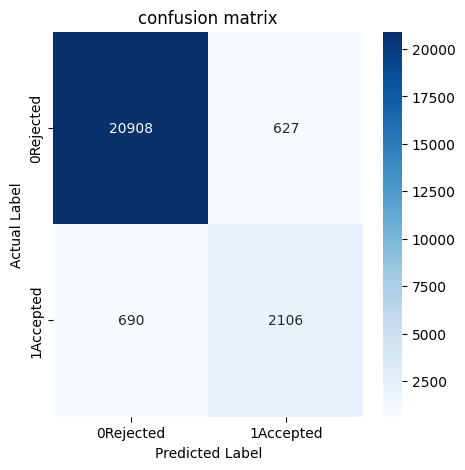

In [ ]:
#confusion matrix figure
plt.figure(figsize=(5,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["0Rejected", "1Accepted"], yticklabels=["0Rejected", "1Accepted"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("confusion matrix")
plt.show()

### 1.5 Analysis

**Class distribution:** The dataset is heavily imbalanced — 71,858 rejected (88.6%) vs. 9,245 accepted (11.4%) applications.

**Features used:** `amount` (float64), `fico` (float64), `dti` (float64), `emp_years` (float64). All are continuous financial indicators.

**Model:** Decision tree with entropy criterion, no depth limit, default sklearn hyperparameters.

**Performance (baseline):**
- Accuracy: 94.59%
- Precision: 77.06%
- Recall: 75.32%
- F1 Score: 76.18%

**Confusion matrix:**
```
[[20908   627]
 [  690  2106]]
```

While overall accuracy is high, the model's performance on accepted loans (the minority class) is moderate. Given the class imbalance, precision and recall are more informative metrics. The model is likely not yet reliable enough for high-stakes lending decisions without further optimization.

## Part 2: Model Optimization

Building on the baseline, I explore five optimization strategies. All experiments use the same baseline feature set (amount, fico, dti, emp_length_numeric) unless otherwise noted, with a 70/30 train/test split as the control group.

### 2.0 Pre-processing Baseline

In [ ]:
# Import key packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read csv file
lcdf = pd.read_csv("/content/drive/MyDrive/MSSP 6080/lendingclub.csv")
#lcdf.head(10)
print(lcdf.dtypes)

amount         float64
date            object
title           object
fico           float64
dti            float64
zip             object
state           object
emp_length      object
policy_code    float64
year             int64
outcome         object
dtype: object


In [ ]:
X_pre = lcdf[["amount", "fico", "dti"]]
y_pre = lcdf["policy_code"]

In [ ]:
# Do your standard train/test split
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(X_pre, y_pre, test_size=0.30, random_state=1, stratify=y_pre) #30% testing data, 70% training data, stratify=y

In [ ]:
# Model
model_pre = DecisionTreeClassifier(criterion="entropy", random_state=1).fit(X_train_pre, y_train_pre) #use entropy as criterion

In [ ]:
y_pred_pre = model_pre.predict(X_test_pre)

accuracy_pre = accuracy_score(y_test_pre,y_pred_pre) # Accuracy
f1_pre = f1_score(y_test_pre, y_pred_pre) #F1 score
precision_pre = precision_score(y_test_pre, y_pred_pre) #Precision
recall_pre = recall_score(y_test_pre, y_pred_pre) #Recall
conf_matrix_pre = confusion_matrix(y_test_pre, y_pred_pre) # Labeled confusion matrix

print(f"Confusion Matrix:\n {conf_matrix_pre}")

Confusion Matrix:
 [[20799   758]
 [  793  1981]]


In [ ]:
tn_pre = 20799
fp_pre = 758
fn_pre = 793
tp_pre = 1981
specificity_pre = tn_pre / (tn_pre + fp_pre)

print("Pre-processing")
print(f"Accuracy: {accuracy_pre:.4f}\n")
print(f"Precision: {precision_pre:.4f}\n")
print(f"Recall: {recall_pre:.4f}\n")
print(f"Specificity: {specificity_pre:.4f}\n")
print(f"F1 Score: {f1_pre:.4f}\n")

Pre-processing
Accuracy: 0.9363

Precision: 0.7233

Recall: 0.7141

Specificity: 0.9648

F1 Score: 0.7187



### 2.1 Feature Engineering: Adding Geographic Region and Loan Purpose

I engineer two new features: (1) geographic region dummy variables derived from borrower state, and (2) a binary indicator for debt-related loan purposes. I test each addition separately against the baseline.

#### Option A: Geographic Region (dummy variables)

In [ ]:
unique_states = lcdf["state"].unique()
print("Unique states:", unique_states)

Unique states: ['GA' 'CA' 'FL' 'NJ' 'PA' 'MN' 'KS' 'LA' 'OR' 'MD' 'AR' 'AZ' 'CO' 'MT'
 'MA' 'NY' 'IL' 'TX' 'WA' 'KY' 'OH' 'WI' 'NC' 'CT' 'MI' 'SC' 'VA' 'WV'
 'RI' 'AL' 'NV' 'MO' 'OK' 'UT' 'AK' 'HI' 'VT' 'NH' 'NM' 'SD' 'DE' 'DC'
 'WY' 'MS' 'ID' 'TN' 'IN' 'ME' 'IA' 'NE' 'ND']


In [ ]:
Midwest = ['MN','IA','MO','WI','IL',"MI",'IN','OH','KY'] #9
Northeast = ['ME','NH','VT','MA','CT','NY','RI','NJ','PA','DE','MD','DC','WV','VA'] #14
Pacific_west = ['AK','WA','OR','ID','CA','NV','UT','AZ','HI'] #9
Plains = ['MT','ND','WY','SD','NE','CO','KS','NM','OK','TX'] #10
Southeast = ['AR','LA','TN','MS','AL','NC','SC','GA','FL'] #9

In [ ]:
print("Dataset columns:", lcdf.columns)

Dataset columns: Index(['amount', 'date', 'title', 'fico', 'dti', 'zip', 'state', 'emp_length',
       'policy_code', 'year', 'outcome'],
      dtype='object')


In [ ]:
region = []
for i in np.arange(len(lcdf.state)):
    if lcdf.iloc[i, 6] in Midwest:
        region.append("midwest")
    elif lcdf.iloc[i, 6] in Northeast:
        region.append("northeast")
    elif lcdf.iloc[i, 6] in Pacific_west:
        region.append("pacific_west")
    elif lcdf.iloc[i, 6] in Plains:
        region.append("plains")
    elif lcdf.iloc[i, 6] in Southeast:
        region.append("southeast")
    else:
        region.append("other")

lcdf["region"] = region

In [ ]:
# create a dataframe with just the regions
region_options = lcdf.region.unique()
regions_df = pd.DataFrame(region_options, columns=['region'])
# generate binary values using get_dummies
dum_df = pd.get_dummies(regions_df, columns=["region"], prefix=["Region_is"] )
# merge to create a dataframe with regions and corresponding dummy variable values
regions_df = regions_df.join(dum_df)
regions_df.head()

,region,Region_is_midwest,Region_is_northeast,Region_is_pacific_west,Region_is_plains,Region_is_southeast
0,southeast,False,False,False,False,True
1,pacific_west,False,False,True,False,False
2,northeast,False,True,False,False,False
3,midwest,True,False,False,False,False
4,plains,False,False,False,True,False


In [ ]:
lcdf = lcdf.merge(regions_df)

In [ ]:
region_columns = ["Region_is_midwest", "Region_is_northeast", "Region_is_pacific_west", "Region_is_plains", "Region_is_southeast"]
region_means = lcdf.groupby("region")[region_columns].mean()
print(region_means)

              Region_is_midwest  Region_is_northeast  Region_is_pacific_west  \
region                                                                         
midwest                     1.0                  0.0                     0.0   
northeast                   0.0                  1.0                     0.0   
pacific_west                0.0                  0.0                     1.0   
plains                      0.0                  0.0                     0.0   
southeast                   0.0                  0.0                     0.0   

              Region_is_plains  Region_is_southeast  
region                                               
midwest                    0.0                  0.0  
northeast                  0.0                  0.0  
pacific_west               0.0                  0.0  
plains                     1.0                  0.0  
southeast                  0.0                  1.0  


In [ ]:
# and add the 5 region dummy variables in to your X (8 variables in total). The y is the same (policy code).
X_option1 = lcdf[["amount", "fico", "dti"] + region_columns]
y_option1 = lcdf["policy_code"]

X_train_option1, X_test_option1, y_train_option1, y_test_option1 = train_test_split(
    X_option1, y_option1, test_size=0.30, random_state=1, stratify=y_option1)

model_option1 = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=1).fit(X_train_option1, y_train_option1)

In [ ]:
y_pred_option1 = model_option1.predict(X_test_option1)

accuracy_option1 = accuracy_score(y_test_option1, y_pred_option1)
precision_option1 = precision_score(y_test_option1, y_pred_option1)
recall_option1 = recall_score(y_test_option1, y_pred_option1)
f1_option1 = f1_score(y_test_option1, y_pred_option1)

conf_matrix_option1 = confusion_matrix(y_test_option1, y_pred_option1)
print(f"Confusion Matrix:\n {conf_matrix_option1}")

Confusion Matrix:
 [[20418  1139]
 [ 1035  1739]]


In [ ]:
tn_option1 = 20418
fp_option1 = 1139
fn_option1 = 1035
tp_option1 = 1739
specificity_option1 = tn_option1 / (tn_option1 + fp_option1)

print("Option1")
print(f"Accuracy: {accuracy_option1:.4f}\n")
print(f"Precision: {precision_option1:.4f}\n")
print(f"Recall: {recall_option1:.4f}\n")
print(f"Specificity: {specificity_option1:.4f}\n")
print(f"F1 Score: {f1_option1:.4f}")

Option1
Accuracy: 0.9106

Precision: 0.6042

Recall: 0.6269

Specificity: 0.9472

F1 Score: 0.6154


#### Option B: Debt-Related Loan Indicator

In [ ]:
 # a.	Replace employment length values <1 and 10+ years to 0 and 11, respectively
lcdf["emp_length"].replace("< 1 year",0, inplace=True)  #replace values less than 1 year to 0
lcdf["emp_length"].replace("10+ years",11, inplace=True)  #replace values more than 10 year to 11

# b.	Create/add new column for new float variable
emp_length_numeric = []

for i in np.arange(len(lcdf.emp_length)):
    years_string = str(lcdf.iloc[i, lcdf.columns.get_loc("emp_length")]).split()
    years_float = float(years_string[0]) if years_string[0].isdigit() else 0
    emp_length_numeric.append(years_float)

lcdf["emp_length_numeric"] = emp_length_numeric
print(lcdf.columns)

<ipython-input-20-b81ffa6feea4>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lcdf["emp_length"].replace("< 1 year",0, inplace=True)  #replace values less than 1 year to 0
<ipython-input-20-b81ffa6feea4>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'd

Index(['amount', 'date', 'title', 'fico', 'dti', 'zip', 'state', 'emp_length',
       'policy_code', 'year', 'outcome', 'region', 'Region_is_midwest',
       'Region_is_northeast', 'Region_is_pacific_west', 'Region_is_plains',
       'Region_is_southeast', 'emp_length_numeric'],
      dtype='object')


In [ ]:
# and add the new float employment length variable. The y is the same (policy code).
X_option2 = lcdf[["amount", "fico", "dti", "emp_length_numeric"]]
y_option2 = lcdf["policy_code"]

X_train_option2, X_test_option2, y_train_option2, y_test_option2 = train_test_split(
    X_option2, y_option2, test_size=0.30, random_state=1, stratify=y_option2)

model_option2 = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=1).fit(X_train_option2, y_train_option2)

In [ ]:
y_pred_option2 = model_option2.predict(X_test_option2)

accuracy_option2 = accuracy_score(y_test_option2, y_pred_option2)
precision_option2 = precision_score(y_test_option2, y_pred_option2)
recall_option2 = recall_score(y_test_option2, y_pred_option2)
f1_option2 = f1_score(y_test_option2, y_pred_option2)

conf_matrix_option2 = confusion_matrix(y_test_option2, y_pred_option2)
print(f"Confusion Matrix:\n {conf_matrix_option2}")

Confusion Matrix:
 [[20487  1070]
 [  719  2055]]


In [ ]:
tn_option2 = 20487
fp_option2 = 1070
fn_option2 = 719
tp_option2 = 2055
specificity_option2 = tn_option2 / (tn_option2 + fp_option2)

print("Option2")
print(f"Accuracy: {accuracy_option2:.4f}\n")
print(f"Precision: {precision_option2:.4f}\n")
print(f"Recall: {recall_option2:.4f}\n")
print(f"Specificity: {specificity_option2:.4f}\n")
print(f"F1 Score: {f1_option2:.4f}")

Option2
Accuracy: 0.9265

Precision: 0.6576

Recall: 0.7408

Specificity: 0.9504

F1 Score: 0.6967


In [ ]:
# create a binary variable to distinguish these types of loans from other types.
is_debt_related = []

for i in np.arange(len(lcdf.title)):
  if "debt" in lcdf.iloc[i, 2].lower():
    is_debt_related.append(1)
  else:
    is_debt_related.append(0)

lcdf["is_debt_related"] = is_debt_related

In [ ]:
# and add the new debt related indicator variable. The y is the same (policy code).
X_option3 = lcdf[["amount", "fico", "dti", "is_debt_related"]]
y_option3 = lcdf["policy_code"]

X_train_option3, X_test_option3, y_train_option3, y_test_option3 = train_test_split(
    X_option3, y_option3, test_size=0.30, random_state=1, stratify=y_option3)

model_option3 = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=1).fit(X_train_option3, y_train_option3)

In [ ]:
y_pred_option3 = model_option3.predict(X_test_option3)

accuracy_option3 = accuracy_score(y_test_option3, y_pred_option3)
precision_option3 = precision_score(y_test_option3, y_pred_option3)
recall_option3 = recall_score(y_test_option3, y_pred_option3)
f1_option3 = f1_score(y_test_option3, y_pred_option3)

conf_matrix_option3 = confusion_matrix(y_test_option3, y_pred_option3)
print(f"Confusion Matrix:\n {conf_matrix_option3}")

Confusion Matrix:
 [[20414  1143]
 [ 1039  1735]]


In [ ]:
tn_option3 = 20414
fp_option3 = 1143
fn_option3 = 1039
tp_option3 = 1735
specificity_option3 = tn_option3 / (tn_option3 + fp_option3)

print("Option3")
print(f"Accuracy: {accuracy_option3:.4f}\n")
print(f"Precision: {precision_option3:.4f}\n")
print(f"Recall: {recall_option3:.4f}\n")
print(f"Specificity: {specificity_option3:.4f}\n")
print(f"F1 Score: {f1_option3:.4f}\n")

Option3
Accuracy: 0.9103

Precision: 0.6028

Recall: 0.6255

Specificity: 0.9470

F1 Score: 0.6139



### 2.2 Training Set Size

I vary the proportion of data used for training (70%, 80%, 90%) while holding features and model architecture constant, to assess how data availability affects performance.

In [ ]:
 # (amount, fico, dti, employment length numeric)
 # Adjust test size
train_sizes_part1 = [0.7, 0.8, 0.9]
train_results_part1 = []

In [ ]:
for train_size_part1 in train_sizes_part1:
# X_option2 = lcdf[["amount", "fico", "dti", "emp_length_numeric"]]
# y_option2 = lcdf["policy_code"]

  X_train_part1, X_test_part1, y_train_part1, y_test_part1 = train_test_split(
      X_option2, y_option2, test_size = 1-train_size_part1, random_state=1, stratify=y_option2)

  model_part1 = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=1).fit(X_train_part1, y_train_part1)
  y_pred_part1 = model_part1.predict(X_test_part1)

  accuracy_part1 = accuracy_score(y_test_part1, y_pred_part1)
  precision_part1 = precision_score(y_test_part1, y_pred_part1)
  recall_part1 = recall_score(y_test_part1, y_pred_part1)
  f1_part1 = f1_score(y_test_part1, y_pred_part1)

  conf_matrix_part1 = confusion_matrix(y_test_part1, y_pred_part1)
  tn_part1, fp_part1, fn_part1, tp_part1 = conf_matrix_part1.ravel()
  specificity_part1 = tn_part1 / (tn_part1 + fp_part1)

  train_results_part1.append([train_size_part1, accuracy_part1, precision_part1, recall_part1, specificity_part1, f1_part1])

In [ ]:
results_part1 = pd.DataFrame(train_results_part1, columns=["Training Size", "Accuracy", "Precision", "Recall", "Specificity", "F1 Score"])
print(results_part1)

   Training Size  Accuracy  Precision    Recall  Specificity  F1 Score
0            0.7  0.926472   0.657600  0.740807     0.950364  0.696728
1            0.8  0.926330   0.659357  0.731747     0.951364  0.693668
2            0.9  0.928862   0.675758  0.723243     0.955330  0.698695


In Part 1, we examined the impact of different training set sizes on the performance of the decision tree model. We used 70%, 80%, and 90% of the data as the training set, with corresponding test set proportions of 30%, 20%, and 10%, respectively (keeping all other parameters unchanged). The results are shown in the code output above.

The results indicate that **accuracy** slightly decreased from 0.9265 (70%) to 80%, before increasing to 0.9289 (90%). However, the improvement remains relatively small, suggesting that increasing the training data size helps improve model accuracy, but not significantly. **Precision** increased as the training data size grew, from 0.6576 (70%) to 0.6758 (90%), indicating an improvement in the model's accuracy in predicting successful loans. **Recall** decreased as the training data size increased, from 0.7408 (70%) to 0.7232 (90%), indicating that as the training data grew, the model became more conservative in predicting successful loans, leading to some truly successful cases being misclassified as failures. **Specificity** increased from 0.9504 (70%) to 0.9553 (90%), indicating an improvement in the model's ability to identify loan failures accurately. The **F1 Score** remained relatively stable because it balances precision and recall. Although recall decreased, the precision improved, offsetting the impact and keeping the F1 Score consistent.

The above analysis suggests that if the goal is to increase the loan approval rate by maximizing recall, using 70% training data is more suitable. If the goal is to reduce incorrect loan approvals by maximizing precision, using 90% training data is more suitable.

### 2.3 Feature Subset Selection

I evaluate four different feature combinations to determine which set of borrower attributes best predicts loan acceptance.

In [ ]:
feature_sets_part2 = [["amount", "fico", "dti"],
                      ["amount", "fico", "dti", "emp_length_numeric"],
                      ["amount", "fico", "dti", "emp_length_numeric", "is_debt_related"],
                      ["amount", "fico", "dti", "emp_length_numeric", "is_debt_related","Region_is_midwest", "Region_is_northeast", "Region_is_pacific_west", "Region_is_plains", "Region_is_southeast"]]
train_results_part2 = []

In [ ]:
for features_part2 in feature_sets_part2:
  X_subset_part2 = lcdf[features_part2]
  # y_option2 = lcdf["policy_code"]

  X_train_part2, X_test_part2, y_train_part2, y_test_part2 = train_test_split(
      X_subset_part2, y_option2, test_size = 0.3, random_state=1, stratify=y_option2)

  model_part2 = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=1).fit(X_train_part2, y_train_part2)
  y_pred_part2 = model_part2.predict(X_test_part2)

  accuracy_part2 = accuracy_score(y_test_part2, y_pred_part2)
  precision_part2 = precision_score(y_test_part2, y_pred_part2)
  recall_part2 = recall_score(y_test_part2, y_pred_part2)
  f1_part2 = f1_score(y_test_part2, y_pred_part2)

  conf_matrix_part2 = confusion_matrix(y_test_part2, y_pred_part2)
  tn_part2, fp_part2, fn_part2, tp_part2 = conf_matrix_part2.ravel()
  specificity_part2 = tn_part2 / (tn_part2 + fp_part2)

  train_results_part2.append([", ".join(features_part2), accuracy_part2, precision_part2, recall_part2, specificity_part2, f1_part2])

In [ ]:
results_part2 = pd.DataFrame(train_results_part2, columns=["Feature Set", "Accuracy", "Precision", "Recall", "Specificity", "F1 Score"])
print(results_part2)

                                         Feature Set  Accuracy  Precision  \
0                                  amount, fico, dti  0.910485   0.603616   
1              amount, fico, dti, emp_length_numeric  0.926472   0.657600   
2  amount, fico, dti, emp_length_numeric, is_debt...  0.923184   0.644338   
3  amount, fico, dti, emp_length_numeric, is_debt...  0.923143   0.644409   

     Recall  Specificity  F1 Score  
0  0.625811     0.947117  0.614513  
1  0.740807     0.950364  0.696728  
2  0.728190     0.948277  0.683703  
3  0.727109     0.948369  0.683266  


In Part 2, we examined how different feature sets affect the performance of the decision tree model. We evaluated four different combinations of features while keeping all other parameters constant. The features were:

Baseline Model: ["amount", "fico", "dti"]

Adding Employment Length: ["amount", "fico", "dti", "emp_length_numeric"]

Adding Debt-Related Indicator: ["amount", "fico", "dti", "emp_length_numeric", "is_debt_related"]

Adding Regional Information: ["amount", "fico", "dti", "emp_length_numeric", "is_debt_related", "Region_is_midwest", "Region_is_northeast", "Region_is_pacific_west", "Region_is_plains", "Region_is_southeast"]

The results are shown in the code output above.

1. Adding Employment Length
When emp_length_numeric was added, accuracy increased from 0.9105 to 0.9265. Precision improved significantly from 0.6036 to 0.6576. Recall also increased from 0.6258 to 0.7408. Specificity improved from 0.9471 to 0.9504. F1 Score improved from 0.6145 to 0.6967. The results indicate that adding Employment Length improved all metrics.

2. Adding Debt Indicator
When is_debt_related was added, accuracy dropped from 0.9265 to 0.9232. Precision dropped from 0.6576 to 0.6443. Recall decreased slightly from 0.7408 to 0.7282. F1 Score also decreased from 0.6967 to 0.6837. Therefore, "is_debt_related" did not improve the model and actually slightly reduced its effectiveness.

3. Adding Region
When regional dummy variables were added, all the metrics remained almost the same. Therefore, adding "region" did not contribute to the model.

Therefore, the best model is the one that includes amount, fico, dti, and emp_length_numeric, which is the model in Option 2.

### 2.4 Decision Tree vs. Logistic Regression

I compare the decision tree against logistic regression using identical features to determine whether a linear model might outperform the tree-based approach.

In [ ]:
# Use same features for each model (amount, fico, dti, employment length numeric)
# Keep test size the same for each model

# X_option2 = lcdf[["amount", "fico", "dti", "emp_length_numeric"]]
# y_option2 = lcdf["policy_code"]

X_train_part3, X_test_part3, y_train_part3, y_test_part3 = train_test_split(
X_option2, y_option2, test_size = 0.3, random_state=1, stratify=y_option2)

# Decision tree
model_part3_tree = DecisionTreeClassifier(criterion="entropy", max_depth=10, random_state=1).fit(X_train_part3, y_train_part3)
y_pred_part3_tree = model_part3_tree.predict(X_test_part3)

#Logistic regression
model_part3_logistic = LogisticRegression(random_state=1).fit(X_train_part3, y_train_part3)
y_pred_part3_logistic = model_part3_logistic.predict(X_test_part3)

In [ ]:
def metrics5(y_test, y_pred):
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  conf_matrix = confusion_matrix(y_test, y_pred)
  tn, fp, fn, tp = conf_matrix.ravel()
  specificity = tn / (tn + fp)
  return [accuracy, precision, recall, specificity, f1]

train_results_part3 = [["Decision tree"] + metrics5(y_test_part3, y_pred_part3_tree),
                       ["Logistic regression"] + metrics5(y_test_part3, y_pred_part3_logistic)]
results_part3 = pd.DataFrame(train_results_part3, columns=["Model", "Accuracy", "Precision", "Recall", "Specificity", "F1 Score"])
print(results_part3)

                 Model  Accuracy  Precision    Recall  Specificity  F1 Score
0        Decision tree  0.926472   0.657600  0.740807     0.950364  0.696728
1  Logistic regression  0.893839   0.560635  0.318313     0.967899  0.406070


The results are shown in the code output above.

These results indicate that the Decision Tree model performed significantly better in Accuracy, Precision, Recall and F1 score. And Logistic Regression (0.9679) was slightly higher than Decision Tree (0.9504) in Specificity, meaning it was slightly better at detecting unsuccessful loans. Therefore, in this case, the Decision Tree is the better model.

### 2.5 Hyperparameter Tuning

I apply grid search cross-validation to optimize the decision tree's hyperparameters, including split criterion, maximum depth, and minimum sample thresholds.

In [ ]:
# Use same features for each model (amount, fico, dti, employment length numeric)
# Use decision tree
# Keep test size the same for each model

X_part4 = lcdf.loc[:, ["amount", "fico", "dti", "emp_length_numeric"]]
y_part4 = lcdf.policy_code

#Split the data into testing and training groups, with 30% designated as test data
X_train_part4, X_test_part4, y_train_part4, y_test_part4 = train_test_split(
    X_part4, y_part4, test_size=0.3, random_state=1, stratify=y_part4)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(3, 10),
    'min_samples_split': range(2, 6),
    'min_samples_leaf': range(1, 4)
}

clf = DecisionTreeClassifier()

gs = GridSearchCV(clf,
                  param_grid=param_grid,
                  cv=10,
                  verbose=1,
                  n_jobs=1)

gs.fit(X_train_part4, y_train_part4)

best_params_part4 = gs.best_params_

print(gs.best_score_)
#Result: 0.9269182428023374
print(gs.best_params_)
#Result: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 4}

Fitting 10 folds for each of 168 candidates, totalling 1680 fits
0.9269358453305492
{'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 4}


In [ ]:
# Model with hyperparameter tuning
model_part4_best_params = DecisionTreeClassifier(
    criterion = "gini",
    max_depth = 9,
    min_samples_leaf = 2,
    min_samples_split = 4,
    random_state=1
    ).fit(X_train_part4, y_train_part4)

y_pred_part4_best_params = model_part4_best_params.predict(X_test_part4)

# Model with no tuning
model_part4_no_tuning = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    random_state=1
    ).fit(X_train_part4, y_train_part4)

y_pred_part4_no_tuning = model_part4_no_tuning.predict(X_test_part4)

train_results_part4 = [["Model with hyperparameter tuning"] + metrics5(y_test_part4, y_pred_part4_best_params),
                       ["Model with no tuning"] + metrics5(y_test_part4, y_pred_part4_no_tuning)]
results_part4 = pd.DataFrame(train_results_part4, columns=["Model", "Accuracy", "Precision", "Recall", "Specificity", "F1 Score"])
print(results_part4)

                              Model  Accuracy  Precision    Recall  \
0  Model with hyperparameter tuning  0.925979   0.665645  0.704758   
1              Model with no tuning  0.926472   0.657600  0.740807   

   Specificity  F1 Score  
0     0.954446  0.684644  
1     0.950364  0.696728  


The Model results are shown in the code output above.

The Grid Search results show best_score = 0.9269, with the optimal parameters being:

 'criterion': 'gini',

 'max_depth': 9,

 'min_samples_leaf': 2,

 'min_samples_split': 4

Surprisingly, the model with hyperparameter tuning only slightly improved Precision and Specificity (by less than 1%) while showing a decline in Accuracy, Recall, and F1 Score, indicating no significant improvement. This suggests that the GridSearch results did not perform as well as the default model. The possible reasons could be an improperly set param_grid or an unsuitable choice of GridSearch. However, based on the current results, hyperparameter tuning does not seem necessary.

### 2.6 Cross-Validation: Number of Folds

I vary the number of folds in k-fold cross-validation (k = 3, 5, 7, 10) to assess how this choice affects estimated model performance and variance.

In [ ]:
# Use same features for each model (amount, fico, dti, employment length numeric)
# Use decision tree
# Keep test size the same for each model


X_part5 = lcdf.loc[:, ["amount", "fico", "dti", "emp_length_numeric"]]
y_part5 = lcdf.policy_code

clf_part5 = DecisionTreeClassifier(criterion='gini', max_depth=9, min_samples_leaf=2, min_samples_split=4)

#Define different numbers of folds to try
k_values_part5 = range(2, 10)
train_results_part5 = []

for k in k_values_part5:
  kfold = KFold(n_splits = k, shuffle=True, random_state = 1)
  scores = cross_val_score(clf_part5, X_part5, y_part5, scoring='accuracy', cv=kfold, n_jobs=-1)
  print(f'Accuracy for k = {k}: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))
  f1scores = cross_val_score(clf, X_part5, y_part5, scoring='f1', cv=kfold, n_jobs=-1)
  print(f'F1-scores for k = {k}: %.3f (%.3f)' % (np.mean(f1scores), np.std(f1scores)))

  train_results_part5.append([k, np.mean(scores), np.std(scores), np.mean(f1scores), np.std(f1scores)])

Accuracy for k = 2: 0.926 (0.002)
F1-scores for k = 2: 0.710 (0.037)
Accuracy for k = 3: 0.928 (0.002)
F1-scores for k = 3: 0.750 (0.012)
Accuracy for k = 4: 0.927 (0.002)
F1-scores for k = 4: 0.753 (0.002)
Accuracy for k = 5: 0.929 (0.001)
F1-scores for k = 5: 0.751 (0.012)
Accuracy for k = 6: 0.928 (0.002)
F1-scores for k = 6: 0.755 (0.005)
Accuracy for k = 7: 0.928 (0.003)
F1-scores for k = 7: 0.752 (0.006)
Accuracy for k = 8: 0.929 (0.002)
F1-scores for k = 8: 0.751 (0.010)
Accuracy for k = 9: 0.928 (0.003)
F1-scores for k = 9: 0.757 (0.007)


In [ ]:
results_part5 = pd.DataFrame(train_results_part5, columns= ["K-Folds", "Accuracy Mean", "Accuracy Std", "F1 Score Mean", "F1 Score Std"])
print(results_part5)

   K-Folds  Accuracy Mean  Accuracy Std  F1 Score Mean  F1 Score Std
0        2       0.925749      0.002194       0.710279      0.036846
1        3       0.927993      0.002308       0.750439      0.011727
2        4       0.927093      0.002495       0.752771      0.001598
3        5       0.928609      0.000725       0.750985      0.011574
4        6       0.928338      0.002427       0.754553      0.005372
5        7       0.928412      0.002584       0.752225      0.006354
6        8       0.928930      0.002335       0.750703      0.010088
7        9       0.928153      0.003314       0.756624      0.006577


The Model results are shown in the code output above.

From the results, it is clear that no single model is the best across all metrics, requiring a trade-off. Overall, k=7 has a relatively high F1 Score Mean and Accuracy Mean, making it a good choice.

Additionally, in Option 2, we ran the model with the same variables as in Part 5 ("amount", "fico", "dti", "emp_length_numeric"). The results for Option 2 were Accuracy = 0.9265 and F1 Score = 0.6967. At k=7, the Accuracy Mean = 0.9284 and F1 Score Mean = 0.733382, both showing an improvement compared to Option 2.

## 3. Summary and Best Model

In conclusion, the best metrics for each of the five parts are as follows:

**Control Group:** Option 2, selecting the variables amount, fico, dti, and emp_length_numeric.

Accuracy: 0.9265

Precision: 0.6576

Recall: 0.7408

Specificity: 0.9504

F1 Score: 0.6967


**Part 1:** Changing Training Size to 0.9

Accuracy = 0.928862

Precision = 0.675758

Recall = 0.723243

Specificity = 0.955330

F1 Score = 0.698695


**Part 2:** Same as Option 2, continuing to use amount, fico, dti, and emp_length_numeric.

**Part 3:** Same as Option 2, continuing to use the Decision Tree.

**Part 4:** Same as Option 2, no hyperparameter tuning.

**Part 5:** Selecting k=7

Accuracy Mean = 0.9284

F1 Score Mean = 0.733382

**Therefore,** only Part 1 and Part 5 improved the model, with Part 1 achieving higher Accuracy and Part 5 achieving a higher F1 Score Mean. When ranking the five options from the greatest impact on model performance to the least, I prefer to place Part 1 first, as changing the training size is simpler. The final ranking is:

**Part 1 > Part 5 > Part 2 = Part 3 = Part 4**

The best model is the one from Q2 Part 1, which:

Uses a Decision Tree with

X including "amount", "fico", "dti", "emp_length_numeric",

Y as "policy_code",

test_size = 0.1,

criterion = "entropy",

max_depth = 10,

(random_state = 1).

Unfortunately, the results of this model are **still not as good as** those in Homework 1. However, assuming we have found a better but more complex model, the analysis is as follows:

**“Worth it" Example:**

If borrowers choose LendingClub based on a high approval rate, and investors rely on accurate risk assessments to minimize defaults, then even small improvements in model precision and recall could significantly impact customer trust and platform competitiveness. This would enhance LendingClub’s reputation, attract more high-quality borrowers, and increase investor confidence, ultimately leading to higher transaction volumes and revenue. In such a scenario, the additional effort spent on model optimization would provide a strong competitive advantage.


**"Not Worth it" Example:**
One hypothetical business context where the improvement would not be worth the extra time and effort is if LendingClub's current model already achieves a high accuracy. For most users, a slight increase in accuracy (e.g., from 95.2% to 95.8%) may not be noticeable or impactful, especially in marketing, where the platform would likely advertise “95%+ accuracy” rather than precise decimal improvements. In this case, the time and resources spent on fine-tuning the model might be better invested in other areas such as user experience enhancements, customer research, marketing efforts, or expanding financial products.